#### Project Name: Image Classification
#### DL Algorithm: Convolutional Neural Networks (CNNs)
#### Dataset: CIFAR-10

In [4]:
import keras
import numpy as np
from keras import layers
import matplotlib.pyplot as plt

In [2]:
# load dataset from Keras and split to train and test set
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


Number of classes: 10


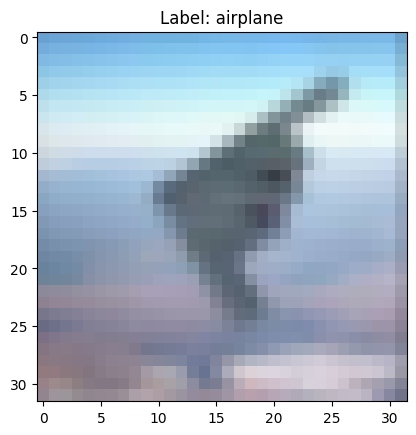

In [28]:
'''
https://keras.io/api/datasets/cifar10/

0	airplane
1	automobile
2	bird
3	cat
4	deer
5	dog
6	frog
7	horse
8	ship
9	truck
'''

class_label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
num_classes = len(class_label)
print(f'Number of classes: {num_classes}')

img_index = 4567
plt.imshow(x_train[img_index])
plt.title("Label: {}".format(class_label[y_train[img_index][0]]))
plt.show()

In [29]:
# build CNN model architecture
model = keras.Sequential(
    [
        keras.Input(shape=(32,32,3)), # Input Layer (no change)
        layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
        layers.Dropout(0.5),
        layers.Flatten(),
        layers.Dense(num_classes, activation="softmax") # Output Layer (no change)
    ]
)

In [30]:
# compile our model
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
es_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# train our model
history = model.fit(x_train, y_train, batch_size = 128, epochs = 80, callbacks = [es_cb], validation_split = 0.2) # 80% of 60000 for training, 20% of 60000 for validation

Epoch 1/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1638 - loss: 5.3666 - val_accuracy: 0.3578 - val_loss: 1.7318
Epoch 2/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3588 - loss: 1.7186 - val_accuracy: 0.4350 - val_loss: 1.5401
Epoch 3/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4300 - loss: 1.5531 - val_accuracy: 0.5069 - val_loss: 1.3825
Epoch 4/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4793 - loss: 1.4315 - val_accuracy: 0.5428 - val_loss: 1.2766
Epoch 5/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5139 - loss: 1.3513 - val_accuracy: 0.5672 - val_loss: 1.2133
Epoch 6/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5394 - loss: 1.2940 - val_accuracy: 0.5706 - val_loss: 1.2284
Epoch 7/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5643 - loss: 1.2231 - val_accuracy: 0.6043 - val_loss: 1.1143
Epoch 8/80
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5838 - loss: 1.1755 - val_accuracy: 

In [36]:
score = model.evaluate(x_test, y_test, verbose=1)
print(f"Accuracy on test set is: {round(score[1]*100, 2)} %")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6720 - loss: 0.9789
Accuracy on test set is: 67.08 %


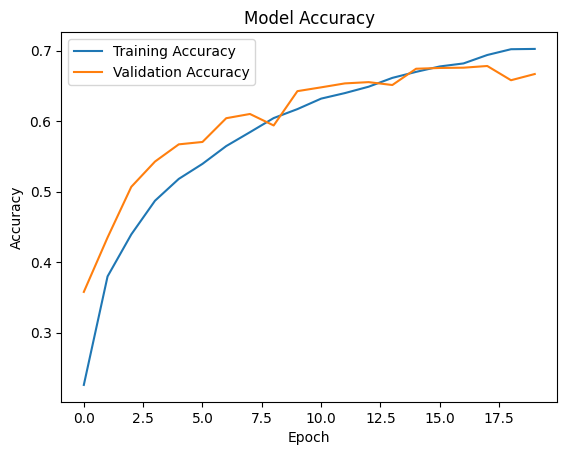

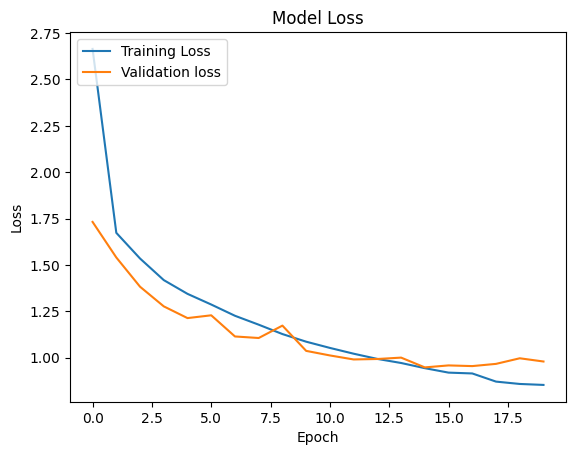

In [41]:
# Plot accuracies
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training Accuracy', 'Validation Accuracy'], loc='upper left')
plt.show()

# Plot losses
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training Loss', 'Validation loss'], loc='upper left')
plt.show()

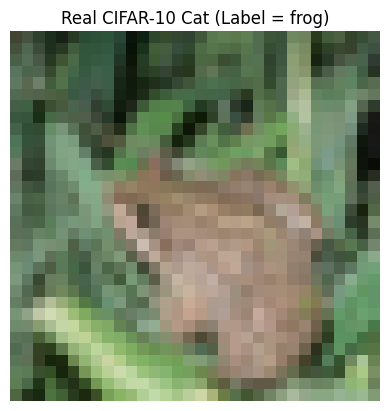

Cat input shape: (1, 32, 32, 3)
Label: frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
True Label: frog
Predicted Label: frog

Prediction Probabilities per Class:
  airplane: 0.0043
automobile: 0.0030
      bird: 0.1594
       cat: 0.1185
      deer: 0.3334
       dog: 0.0267
      frog: 0.3411
     horse: 0.0070
      ship: 0.0044
     truck: 0.0024


In [67]:
# create 1 dummy image and predict
# Find one sample with label = 6 ("frog")
cat_index = np.where(y_test.flatten() == 6)[0][0]
cat_image = x_test[cat_index]
cat_label = int(y_test[cat_index][0])

# Preprocess for model
cat_input = cat_image.astype("float32") / 255.0  # normalize to range[0,1]
cat_input = np.expand_dims(cat_input, axis=0) # (batch size, height, width, channels)

# Show the frog image
plt.imshow(cat_image)
plt.title(f"Real CIFAR-10 Cat (Label = {class_label[cat_label]})")
plt.axis("off")
plt.show()

print("Cat input shape:", cat_input.shape)
print("Label:", class_label[cat_label])

# === Prediction ===
pred_probs = model.predict(cat_input)  # probabilities for the 10 classes
pred_class = np.argmax(pred_probs, axis=1)[0]

# === Print some info. ===
print("True Label:", class_label[cat_label])
print("Predicted Label:", class_label[pred_class])
print("\nPrediction Probabilities per Class:")
for i, prob in enumerate(pred_probs[0]):
    print(f"{class_label[i]:>10}: {prob:.4f}")

In [59]:
model.save('VisionAI_Model.keras')
print('The model is saved successfully.')

The model is saved successfully.
